# **Limpieza final de Dataframe 3 en Python**

# Paso 1 — Carga de CSV en Google Colab, importación de librerías y categorización de columnas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("olist dataf3 shell.csv", sep=";")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34448 entries, 0 to 34447
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seller_id               34448 non-null  object 
 1   seller_city_clean       34448 non-null  object 
 2   seller_state_clean      34448 non-null  object 
 3   product_id              34448 non-null  object 
 4   product_category_name   33838 non-null  object 
 5   product_weight_g        34446 non-null  float64
 6   unidades_vendidas       34448 non-null  int64  
 7   total_pedidos           34448 non-null  int64  
 8   ingreso_total_producto  34448 non-null  float64
 9   ticket_medio            34448 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 2.6+ MB


,seller_id,seller_city_clean,seller_state_clean,product_id,product_category_name,product_weight_g,unidades_vendidas,total_pedidos,ingreso_total_producto,ticket_medio
0,0015a82c2db000af6aaaf3ae2ecb0532,santo andre,sp,a2ff5a97bf95719e38ea2e3b4105bce8,eletroportateis,11800.0,3,3,2685.00,895.000.000
1,001cca7ae9ae17fb1caed9dfb1094831,cariacica,es,08574b074924071f4e201e151b152b4e,ferramentas_jardim,9000.0,113,97,10759.30,110.920.619
2,001cca7ae9ae17fb1caed9dfb1094831,cariacica,es,0da9ffd92214425d880de3f94e74ce39,construcao_ferramentas_construcao,10900.0,17,16,1819.93,113.745.625
3,001cca7ae9ae17fb1caed9dfb1094831,cariacica,es,21fecd254a3103704126b28478ea7980,ferramentas_jardim,7400.0,3,3,337.00,112.333.333
4,001cca7ae9ae17fb1caed9dfb1094831,cariacica,es,4d7fee7877228c1497477ae53d97c214,construcao_ferramentas_construcao,8650.0,2,2,178.00,89.000.000


# 2. Normalizar cadenas (lower, trim)


In [2]:
text_cols = ['seller_city_clean', 'seller_state_clean', 'product_category_name']
for col in text_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()
    df[col] = df[col].replace('nan', np.nan) # Convertir los 'nan' de texto a nulos reales

# 3. Corregir tipos numéricos - El ticket medio viene mal formateado (ej. 895.000.000), lo recalculamos de forma segura

In [3]:
df['ticket_medio'] = (df['ingreso_total_producto'] / df['total_pedidos']).round(2)
# Celda 3: Valores faltantes y duplicados
# Python
# 4. Analizar y tratar valores faltantes
print("Nulos antes de limpiar:\n", df.isnull().sum())

Nulos antes de limpiar:
 seller_id                   0
seller_city_clean           0
seller_state_clean          0
product_id                  0
product_category_name     610
product_weight_g            2
unidades_vendidas           0
total_pedidos               0
ingreso_total_producto      0
ticket_medio                0
dtype: int64


In [4]:
df['ticket_medio'] = (df['ingreso_total_producto'] / df['total_pedidos']).round(2)

print("Nulos antes de limpiar:\n", df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())

Nulos antes de limpiar:
 seller_id                   0
seller_city_clean           0
seller_state_clean          0
product_id                  0
product_category_name     610
product_weight_g            2
unidades_vendidas           0
total_pedidos               0
ingreso_total_producto      0
ticket_medio                0
dtype: int64

Filas duplicadas: 0


# 4. Analizar y tratar valores faltantes

In [5]:
print("Nulos antes de limpiar:\n", df.isnull().sum())

Nulos antes de limpiar:
 seller_id                   0
seller_city_clean           0
seller_state_clean          0
product_id                  0
product_category_name     610
product_weight_g            2
unidades_vendidas           0
total_pedidos               0
ingreso_total_producto      0
ticket_medio                0
dtype: int64


# Decisión: Los productos sin categoría se etiquetan para no perder ventas

In [6]:
df['product_category_name'] = df['product_category_name'].fillna('sin_categoria')

# Decisión: Los pesos faltantes se imputan con la mediana

In [7]:
if df['product_weight_g'].isnull().sum() > 0:
    df['product_weight_g'] = df['product_weight_g'].fillna(df['product_weight_g'].median())



# 5. Verificar y eliminar duplicados

In [8]:
print(f"Filas duplicadas encontradas: {df.duplicated().sum()}")
df = df.drop_duplicates()


Filas duplicadas encontradas: 0


# 6. Crear columnas derivadas útiles

# Clasificamos a los vendedores/productos en 'Top Ventas' si superan el percentil 75

In [9]:
percentil_75 = df['ingreso_total_producto'].quantile(0.75)
df['categoria_rendimiento'] = np.where(df['ingreso_total_producto'] >= percentil_75, 'Top Ventas', 'Estándar')

# 7. Generar visualizaciones para validar distribución y outliers (Boxplot e Histograma)

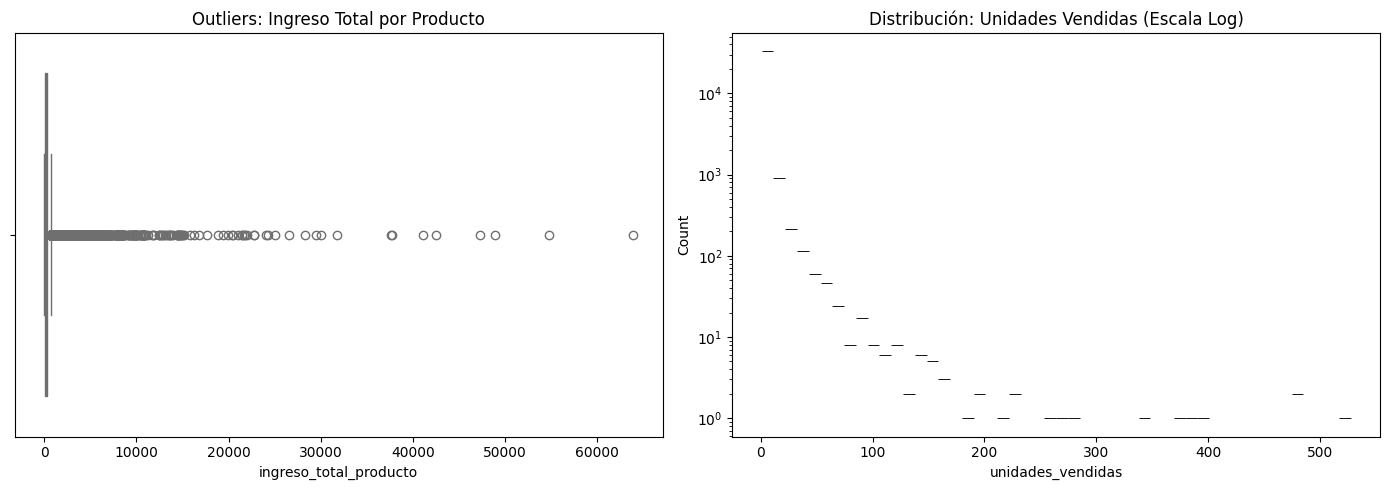

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['ingreso_total_producto'], ax=axes[0], color='skyblue')
axes[0].set_title('Outliers: Ingreso Total por Producto')

sns.histplot(df['unidades_vendidas'], bins=50, ax=axes[1], color='salmon', log_scale=(False, True))
axes[1].set_title('Distribución: Unidades Vendidas (Escala Log)')

plt.tight_layout()
plt.show()

# 8. Exportar dataset final limpio para el Proyecto IV

In [ ]:
df.to_csv("vendedores_limpio.csv", index=False, sep=",")
print("Dataset limpio exportado con éxito.")

Dataset limpio exportado con éxito.
